<a href="https://colab.research.google.com/github/sahprahalad754-cmd/Ml-lab-work/blob/main/Naive_Baye's_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
    Outlook Temprature humidity  windy play tennis
0     sunny        hot     high  False          no
1     sunny        hot     high   True          no
2  overcast        hot     high  False         yes
3     rainy       mild     high  False         yes
4     rainy       cold   normal  False         yes

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temprature   14 non-null     object
 2   humidity     14 non-null     object
 3   windy        14 non-null     bool  
 4   play tennis  14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes
None

Columns after encoding:
Index(['windy', 'Outlook_overcast', 'Outlook_rainy', 'Outlook_sunny',
       'Temprature_cold', 'Temprature_hot', 'Temprature_mild', 'humidity_high',
       'humidity_normal', 'play tennis_no'

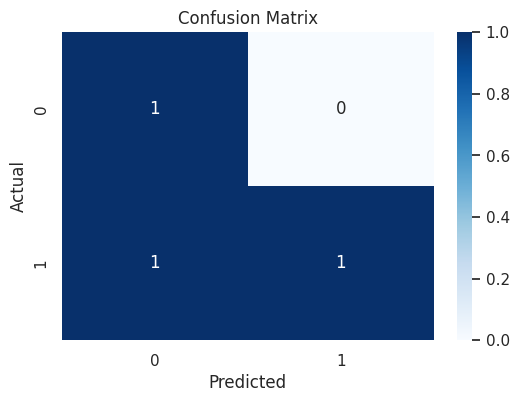

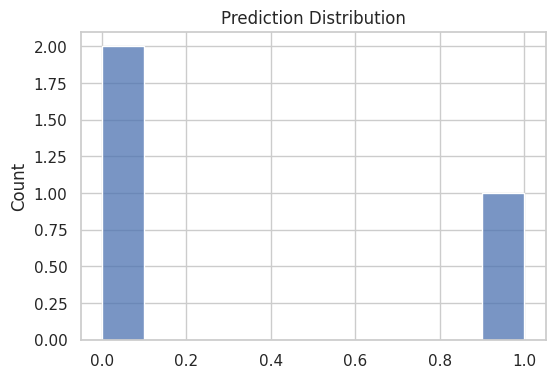

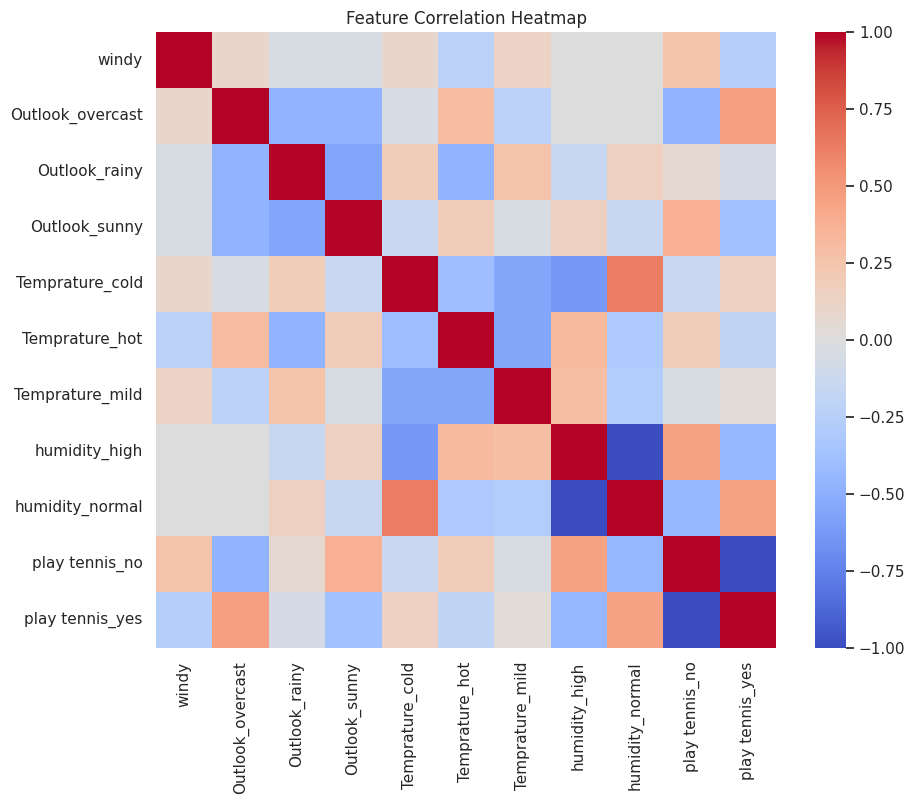

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
df = pd.read_csv("/content/Tennis.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

df = df.dropna()

df = pd.get_dummies(df)

print("\nColumns after encoding:")
print(df.columns)

target_column_name = "play tennis_yes"

X = df.drop(['play tennis_no', 'play tennis_yes'], axis=1)
y = df[target_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(y_pred, bins=10)
plt.title("Prediction Distribution")
plt.show()

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()